In [45]:
import pandas as pd
import matplotlib.pyplot as plt

In [49]:
data = pd.read_csv('bi_dataset/sale_data.csv')

data.head()

,OrderDate,Category,City,Country,CustomerName,Discount,OrderID,PostalCode,ProductName,Profit,...,DaystoShipActual,SalesForecast,ShipStatus,DaystoShipScheduled,OrderProfitable,SalesperCustomer,ProfitRatio,SalesaboveTarget,latitude,longitude
0,2011-01-04T00:00:00.000Z,Office Supplies,Houston,United States,Darren Powers,0.2,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",6,...,4,22,Shipped Early,6,NaN,16.45,33.8,NaN,29.8941,-95.6481
1,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,Avery 508,4,...,4,15,Shipped Early,6,NaN,11.78,36.3,NaN,41.7662,-88.1410
2,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.8,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,-5,...,4,5,Shipped Early,6,NaN,3.54,-155.0,NaN,41.7662,-88.1410
3,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,-65,...,4,357,Shipped Early,6,NaN,272.74,-23.8,NaN,41.7662,-88.1410
4,2011-01-06T00:00:00.000Z,Office Supplies,Philadelphia,United States,Mick Brown,0.2,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,5,...,7,26,Shipped Late,6,NaN,19.54,25.0,NaN,39.9448,-75.2288


In [53]:
print(data.columns)

Index(['OrderDate', 'Category', 'City', 'Country', 'CustomerName', 'Discount',
       'OrderID', 'PostalCode', 'ProductName', 'Profit', 'Quantity', 'Region',
       'Sales', 'Segment', 'ShipDate', 'ShipMode', 'State', 'Sub_Category',
       'DaystoShipActual', 'SalesForecast', 'ShipStatus',
       'DaystoShipScheduled', 'OrderProfitable', 'SalesperCustomer',
       'ProfitRatio', 'SalesaboveTarget', 'latitude', 'longitude'],
      dtype='object')


In [55]:
# Convert to uppercase
data.columns = data.columns.str.upper()

# Fill missing values
data = data.fillna(data.mean(numeric_only=True))
data = data.fillna('Unknown')

data.head()

,ORDERDATE,CATEGORY,CITY,COUNTRY,CUSTOMERNAME,DISCOUNT,ORDERID,POSTALCODE,PRODUCTNAME,PROFIT,...,DAYSTOSHIPACTUAL,SALESFORECAST,SHIPSTATUS,DAYSTOSHIPSCHEDULED,ORDERPROFITABLE,SALESPERCUSTOMER,PROFITRATIO,SALESABOVETARGET,LATITUDE,LONGITUDE
0,2011-01-04T00:00:00.000Z,Office Supplies,Houston,United States,Darren Powers,0.2,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2 X 4 Forms/...",6,...,4,22,Shipped Early,6,Unknown,16.45,33.8,Unknown,29.8941,-95.6481
1,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,Avery 508,4,...,4,15,Shipped Early,6,Unknown,11.78,36.3,Unknown,41.7662,-88.1410
2,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.8,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,-5,...,4,5,Shipped Early,6,Unknown,3.54,-155.0,Unknown,41.7662,-88.1410
3,2011-01-05T00:00:00.000Z,Office Supplies,Naperville,United States,Phillina Ober,0.2,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,-65,...,4,357,Shipped Early,6,Unknown,272.74,-23.8,Unknown,41.7662,-88.1410
4,2011-01-06T00:00:00.000Z,Office Supplies,Philadelphia,United States,Mick Brown,0.2,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,5,...,7,26,Shipped Late,6,Unknown,19.54,25.0,Unknown,39.9448,-75.2288


In [57]:
data['PROFIT_MARGIN'] = data['PROFIT'] / data['SALES']

In [59]:
data.to_csv('processed_data.csv', index=False)

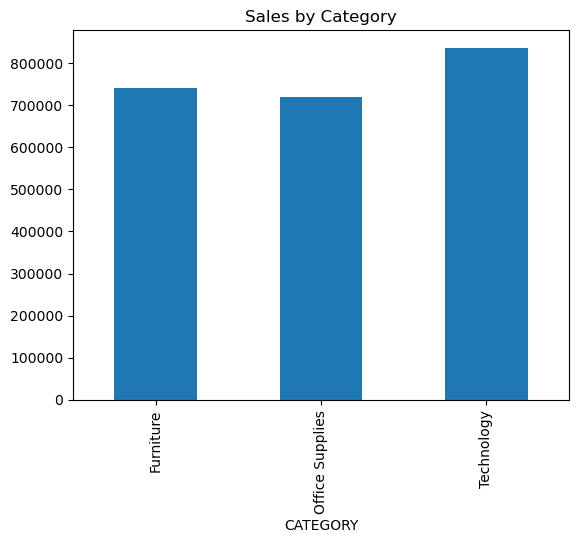

In [61]:
data.groupby('CATEGORY')['SALES'].sum().plot(kind='bar')

plt.title("Sales by Category")
plt.show()

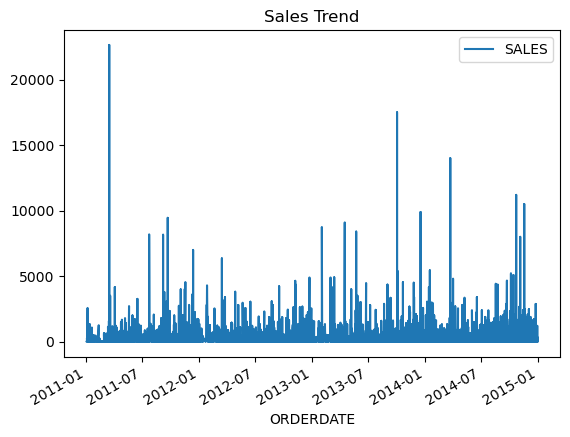

In [63]:
# Convert date
data['ORDERDATE'] = pd.to_datetime(data['ORDERDATE'])

data.sort_values('ORDERDATE').plot(x='ORDERDATE', y='SALES')

plt.title("Sales Trend")
plt.show()

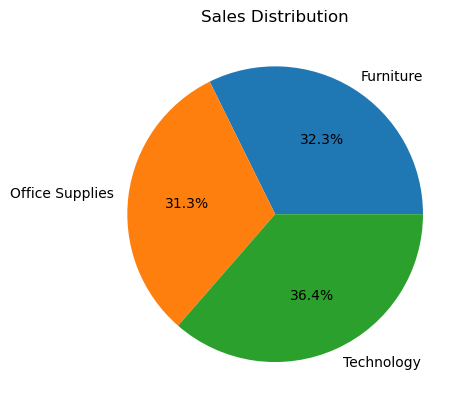

In [65]:
data.groupby('CATEGORY')['SALES'].sum().plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales Distribution")
plt.ylabel("")
plt.show()